This notebook will check some assumptions that need to be bet so that we don't produce biased estimates of ATE using Two Way Fixed Effects

In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import pyfixest as pf

In [2]:
#bring in cell day dataframe

#bring in data

df = pd.read_parquet("E:\\tfl_project\cell_day_with_tube_features.parquet")

df.columns

Index(['h3_cell', 'day', 'total_trips', 'n_stations', 'frac_exposed',
       'temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain',
       'doy', 'cloud_cover', 'wind_speed_10m', 'strike_severity_daily_frac',
       'is_weekend', 'is_bank_holiday', 'is_school_holiday',
       'days_to_next_strike', 'days_since_last_strike', 'cycle_infra_score',
       'y_per_station_log1p', 'dist_nearest_tube_km', 'n_tube_within_500m',
       'n_tube_within_1000m', 'n_tube_within_2000m', 'y_log1p',
       'tube_disruption_approx', 'D_continuous', 'date_str', 'treated'],
      dtype='str')

In [7]:
df.groupby("day").agg({"day": "nunique"}).describe()

,day
count,1081.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [10]:
df.groupby("h3_cell").agg({"h3_cell": "nunique"}).describe()

,h3_cell
count,132.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [3]:
df.shape

(142071, 29)

In [8]:
cell_day = df.copy()

Here we do a placebo test, by shifting the treatment back by 2 weeks and then seeing what the CATE is then

In [9]:
# ── Step 1: Build a proper cell-level placebo ─────────────────────────────────
# For each cell that was treated on day D, flag that same cell on day D-14
# This preserves the geographic targeting of the real treatment

cell_day["date_dt"] = pd.to_datetime(cell_day["day"])

# Get all (cell, strike_date) pairs — not just dates
treated_pairs = (
    cell_day.loc[cell_day["treated"] == 1, ["h3_cell", "date_dt"]]
    .drop_duplicates()
    .copy()
)

# Shift each treated date back 14 days
treated_pairs["placebo_date"] = (
    treated_pairs["date_dt"] - pd.Timedelta(days=14)
)

print(f"Treated cell-days       : {len(treated_pairs):,}")
print(f"Unique strike dates     : {treated_pairs['date_dt'].nunique()}")
print(f"Unique placebo dates    : {treated_pairs['placebo_date'].nunique()}")

# ── Step 2: Check for overlap between placebo dates and real strike dates ──────
real_strike_dates  = set(treated_pairs["date_dt"].dt.normalize().unique())
placebo_date_set   = set(treated_pairs["placebo_date"].dt.normalize().unique())

overlap = real_strike_dates & placebo_date_set
print(f"\nPlacebo dates that overlap with real strike dates: {len(overlap)}")
if overlap:
    print("  Overlapping dates:", sorted(overlap)[:5], "...")
    print("  These will be excluded from the placebo regression")

# ── Step 3: Merge placebo indicator back onto cell_day ─────────────────────────
# Match on BOTH cell identity and date — not just date
placebo_keys = treated_pairs[["h3_cell", "placebo_date"]].rename(
    columns={"placebo_date": "date_dt"}
)
placebo_keys["placebo"] = 1

cell_day = cell_day.merge(
    placebo_keys,
    on=["h3_cell", "date_dt"],
    how="left"
)
cell_day["placebo"] = cell_day["placebo"].fillna(0).astype(int)

# Verify the placebo treatment rate matches the real treatment rate
real_rate   = cell_day["treated"].mean()
placebo_rate = cell_day["placebo"].mean()
print(f"\nReal treatment rate   : {real_rate:.4%}")
print(f"Placebo treatment rate: {placebo_rate:.4%}")
print("(These should be similar — same cells, shifted dates)")

# ── Step 4: Build the clean placebo regression dataset ────────────────────────
# Exclude:
#   (a) actual strike days (treated == 1)
#   (b) any day within 7 days of a strike — avoids anticipation contamination
#   (c) placebo dates that overlap with real strike dates

# Build a set of all dates within 7 days of any strike
all_strike_dates = sorted(real_strike_dates)
buffer_dates = set()
for sd in all_strike_dates:
    for delta in range(-7, 8):
        buffer_dates.add(sd + pd.Timedelta(days=delta))

cell_day["near_strike"] = cell_day["date_dt"].dt.normalize().isin(buffer_dates).astype(int)
cell_day["placebo_on_strike_date"] = (
    cell_day["date_dt"].dt.normalize().isin(overlap)
).astype(int)

placebo_df = cell_day[
    (cell_day["treated"] == 0) &              # exclude real strike days
    (cell_day["near_strike"] == 0) &          # exclude days near strikes
    (cell_day["placebo_on_strike_date"] == 0) # exclude contaminated placebo dates
].copy()

print(f"\nRows in placebo regression dataset: {len(placebo_df):,}")
print(f"Placebo treated rows              : {placebo_df['placebo'].sum():,}")
print(f"Placebo treatment rate in sample  : {placebo_df['placebo'].mean():.4%}")

# ── Step 5: Fit the placebo TWFE ───────────────────────────────────────────────
twfe_placebo = smf.ols(
    "y_per_station_log1p ~ placebo + C(h3_cell) + C(date_str)",
    data=placebo_df,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": placebo_df["h3_cell"]},
)

placebo_effect = np.expm1(twfe_placebo.params["placebo"]) * 100
placebo_pval   = twfe_placebo.pvalues["placebo"]
placebo_ci_lo  = np.expm1(twfe_placebo.conf_int().loc["placebo", 0]) * 100
placebo_ci_hi  = np.expm1(twfe_placebo.conf_int().loc["placebo", 1]) * 100

print(f"\nPlacebo ATE : {placebo_effect:+.2f}%")
print(f"95% CI      : [{placebo_ci_lo:.2f}%, {placebo_ci_hi:.2f}%]")
print(f"p-value     : {placebo_pval:.4f}")
print("(Should be close to 0% and not significant)")

# ── Step 6: Compare real vs placebo ───────────────────────────────────────────
print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"Real TWFE ATE   : +10.27%  p=0.0003  ← causal effect")
print(f"Placebo ATE     : {placebo_effect:+.2f}%  p={placebo_pval:.4f}  ← should be ~0")

if placebo_pval > 0.05:
    print("\n✓ Placebo not significant — parallel trends supported")
else:
    print("\n✗ Placebo still significant — investigate further")
    print("  Possible causes:")
    print("  - Strikes cluster in periods with unusual bike demand")
    print("  - School holidays or seasonal effects not fully absorbed")
    print("  - 14-day window too short — try 28 days")

Treated cell-days       : 1,008
Unique strike dates     : 20
Unique placebo dates    : 20

Placebo dates that overlap with real strike dates: 1
  Overlapping dates: [Timestamp('2016-12-25 00:00:00')] ...
  These will be excluded from the placebo regression

Real treatment rate   : 0.7095%
Placebo treatment rate: 0.7095%
(These should be similar — same cells, shifted dates)

Rows in placebo regression dataset: 122,359
Placebo treated rows              : 716
Placebo treatment rate in sample  : 0.5852%

Placebo ATE : +0.42%
95% CI      : [-3.86%, 4.89%]
p-value     : 0.8506
(Should be close to 0% and not significant)

SUMMARY
Real TWFE ATE   : +10.27%  p=0.0003  ← causal effect
Placebo ATE     : +0.42%  p=0.8506  ← should be ~0

✓ Placebo not significant — parallel trends supported


In [8]:
# Placebo: shift treatment back 14 days
# If the cell was treated on day D, flag day D-14 as placebo-treated
strike_dates = set(cell_day.loc[cell_day["treated"] == 1, "day"].astype(str))

cell_day["date_dt"] = pd.to_datetime(cell_day["day"])
placebo_dates = {
    (pd.Timestamp(d) - pd.Timedelta(days=14)).strftime("%Y-%m-%d")
    for d in strike_dates
}

cell_day["placebo"] = cell_day["date_dt"].dt.strftime("%Y-%m-%d").isin(
    placebo_dates
).astype(int)

# Fit the same TWFE model with placebo treatment
twfe_placebo = smf.ols(
    """y_per_station_log1p ~ placebo
       + C(h3_cell) + C(date_str)""",
    data=cell_day[cell_day["treated"] == 0]  # exclude actual strike days
).fit(
    cov_type="cluster",
    cov_kwds={"groups": cell_day.loc[cell_day["treated"] == 0, "h3_cell"]}
)

placebo_effect = np.expm1(twfe_placebo.params["placebo"]) * 100
print(f"Placebo ATE : {placebo_effect:+.2f}%")
print(f"p-value     : {twfe_placebo.pvalues['placebo']:.4f}")
print("(Should be close to 0% and not significant)")

Placebo ATE : +51.71%
p-value     : 0.0000
(Should be close to 0% and not significant)


e:\tfl_project\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
e:\tfl_project\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


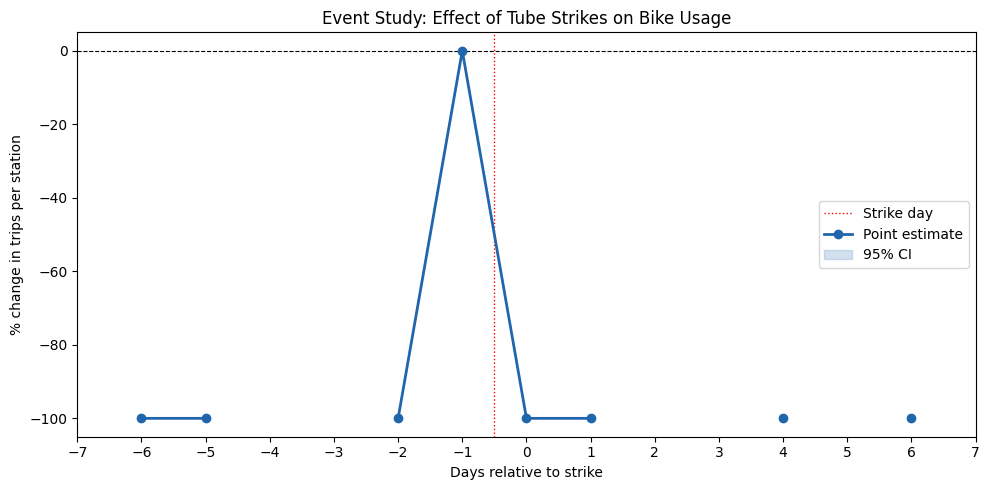


What to look for:
  Pre-treatment (t < 0): coefficients should be near zero (parallel trends)
  t = 0: should show the ~+10% effect
  Post-treatment (t > 0): should return toward zero (temporary strike effect)


In [9]:


# ── Build event-time variable ──────────────────────────────────────────────────
# For each treated cell-day, how many days is it from the strike?
# For non-treated cell-days, assign a large number outside the window

WINDOW = 7   # days before and after strike to study

cell_day["date_dt"] = pd.to_datetime(cell_day["day"])

# Find all strike dates
strike_dates = pd.to_datetime(
    cell_day.loc[cell_day["treated"] == 1, "day"].unique()
)

def compute_event_time(row, strike_dates, window):
    """
    For each observation, find the nearest strike date for that cell
    and compute days relative to it. If outside window, return None.
    """
    if row["treated"] == 1:
        return 0  # the strike day itself is always t=0

    date = pd.Timestamp(row["date_dt"])
    diffs = [(date - s).days for s in strike_dates]

    # Find nearest past or future strike within window
    within = [d for d in diffs if -window <= d <= window and d != 0]
    if not within:
        return None
    return min(within, key=abs)

# This is slow on the full dataset — sample for the plot
sample = cell_day.sample(frac=1, random_state=42).copy()
sample["event_time"] = sample.apply(
    lambda r: compute_event_time(r, strike_dates, WINDOW), axis=1
)

# Keep only observations within the event window
event_df = sample.dropna(subset=["event_time"]).copy()
event_df["event_time"] = event_df["event_time"].astype(int)

# Drop t=-1 as the reference period (standard practice)
event_df = event_df[event_df["event_time"] != -1]

# Interact event_time dummies with treatment
# This gives separate coefficients for each period
event_formula = (
    "y_per_station_log1p ~ "
    "C(event_time) + C(h3_cell) + C(date_str)"
)

event_model = smf.ols(
    event_formula,
    data=event_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": event_df["h3_cell"]}
)

# Extract coefficients for event_time dummies
coef_df = pd.DataFrame({
    "coef": event_model.params,
    "ci_lo": event_model.conf_int()[0],
    "ci_hi": event_model.conf_int()[1],
}).reset_index()

event_coefs = coef_df[coef_df["index"].str.startswith("C(event_time)")].copy()
event_coefs["t"] = (
    event_coefs["index"]
    .str.replace("C(event_time)[T.", "", regex=False)
    .str.replace("]", "", regex=False)
    .astype(int)
)
event_coefs = event_coefs.sort_values("t")

# Add t=-1 reference point (coefficient = 0 by construction)
ref = pd.DataFrame({"t": [-1], "coef": [0.0], "ci_lo": [0.0], "ci_hi": [0.0]})
event_coefs = pd.concat([event_coefs, ref]).sort_values("t")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(x=-0.5, color="red", linewidth=1.0, linestyle=":", label="Strike day")

ax.plot(event_coefs["t"], np.expm1(event_coefs["coef"]) * 100,
        "o-", color="#2166ac", linewidth=2, markersize=6, label="Point estimate")

ax.fill_between(
    event_coefs["t"],
    np.expm1(event_coefs["ci_lo"]) * 100,
    np.expm1(event_coefs["ci_hi"]) * 100,
    alpha=0.2, color="#2166ac", label="95% CI"
)

ax.set_xlabel("Days relative to strike")
ax.set_ylabel("% change in trips per station")
ax.set_title("Event Study: Effect of Tube Strikes on Bike Usage")
ax.set_xticks(range(-WINDOW, WINDOW + 1))
ax.legend()
plt.tight_layout()
plt.savefig("event_study.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nWhat to look for:")
print("  Pre-treatment (t < 0): coefficients should be near zero (parallel trends)")
print("  t = 0: should show the ~+10% effect")
print("  Post-treatment (t > 0): should return toward zero (temporary strike effect)")

In [14]:
def run_event_study(
    cell_day:    pd.DataFrame,
    window_pre:  int = 7,
    window_post: int = 7,
    ref_period:  int = -1,
) -> pd.DataFrame:

    stacked_reg, _ = build_stacked_event_study(
        cell_day, window_pre, window_post, ref_period
    )

    # pyfixest needs string/categorical grouping columns
    stacked_reg["cell_x_dataset"] = (
        stacked_reg["h3_cell"].astype(str) + "_" +
        stacked_reg["dataset_id"].astype(str)
    )
    stacked_reg["date_x_dataset"] = (
        stacked_reg["date_str"].astype(str) + "_" +
        stacked_reg["dataset_id"].astype(str)
    )

    # event_time must be categorical with reference period already excluded
    # pyfixest uses i() syntax for event study dummies with a reference level
    stacked_reg["event_time"] = stacked_reg["event_time"].astype(int)

    print("Fitting stacked event study with pyfixest...")

    model = pf.feols(
        # i(event_time, ref=-1) creates event-time dummies, omitting t=-1
        "y_per_station_log1p ~ i(event_time, ref=-1) | "
        "cell_x_dataset + date_x_dataset",
        data    = stacked_reg,
        vcov    = {"CRV1": "h3_cell"},   # cluster by cell
    )

    print(model.summary())

    # ── Extract coefficients ──────────────────────────────────────────────────
    coef_df = model.coef().reset_index()
    ci_df   = model.confint().reset_index()
    pv_df   = model.pvalue().reset_index()

    coef_df.columns = ["param", "coef"]
    ci_df.columns   = ["param", "ci_lo", "ci_hi"]
    pv_df.columns   = ["param", "pval"]

    results = (
        coef_df
        .merge(ci_df,  on="param")
        .merge(pv_df,  on="param")
    )

    # Keep only event_time coefficients
    results = results[results["param"].str.startswith("event_time::")]

    results["event_time"] = (
        results["param"]
        .str.replace("event_time::", "", regex=False)
        .astype(int)
    )

    # Add reference period at zero
    ref_row = pd.DataFrame({
        "event_time": [ref_period],
        "coef":       [0.0],
        "ci_lo":      [0.0],
        "ci_hi":      [0.0],
        "pval":       [np.nan],
        "param":      [f"event_time::{ref_period}"],
    })

    results = (
        pd.concat([results, ref_row])
        .sort_values("event_time")
        .reset_index(drop=True)
    )

    return results

In [16]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

def build_stacked_event_study(
    cell_day:    pd.DataFrame,
    window_pre:  int = 7,
    window_post: int = 7,
    ref_period:  int = -1,
) -> pd.DataFrame:
    """
    Build a stacked dataset for event study estimation.

    For each unique strike date, extract a clean window of [-window_pre, window_post]
    days around it. Stack all windows together, assigning a dataset_id to each
    so that the fixed effects are estimated within each event window separately.

    This handles the recurring treatment correctly — each strike event gets its
    own clean comparison window rather than bleeding into adjacent events.
    """
    cell_day      = cell_day.copy()
    cell_day["date_dt"] = pd.to_datetime(cell_day["day"])

    # Find all unique strike dates
    strike_dates = sorted(
        cell_day.loc[cell_day["treated"] == 1, "date_dt"]
        .dt.normalize()
        .unique()
    )

    print(f"Found {len(strike_dates)} unique strike dates")

    stacks = []
    for i, strike_date in enumerate(strike_dates):
        window_start = strike_date - pd.Timedelta(days=window_pre)
        window_end   = strike_date + pd.Timedelta(days=window_post)

        # Extract window — exclude the reference period from the regression
        # but keep it in the data so we can verify its values
        window = cell_day[
            (cell_day["date_dt"] >= window_start) &
            (cell_day["date_dt"] <= window_end)
        ].copy()

        if len(window) == 0:
            continue

        # Assign event time relative to this specific strike date
        window["event_time"] = (
            (window["date_dt"].dt.normalize() - strike_date)
            .dt.days
        )

        # Dataset identifier for stacked fixed effects
        window["dataset_id"] = i
        window["strike_date"] = strike_date

        stacks.append(window)

    stacked = pd.concat(stacks, ignore_index=True)

    # Remove the reference period from regression data
    # but verify it exists first
    ref_count = (stacked["event_time"] == ref_period).sum()
    print(f"Reference period (t={ref_period}) observations: {ref_count:,}")
    assert ref_count > 0, f"No observations at reference period t={ref_period}"

    # Exclude reference period — its coefficient is zero by normalisation
    stacked_reg = stacked[stacked["event_time"] != ref_period].copy()

    print(f"Stacked dataset: {len(stacked_reg):,} observations")
    print(f"Event-time distribution:")
    print(stacked_reg["event_time"].value_counts().sort_index())

    return stacked_reg, stacked


def run_event_study(
    cell_day:    pd.DataFrame,
    window_pre:  int  = 7,
    window_post: int  = 7,
    ref_period:  int  = -1,
) -> pd.DataFrame:
    """
    Estimate event study coefficients using a stacked DiD design.
    Returns DataFrame of event-time coefficients with confidence intervals.
    """
    stacked_reg, stacked_full = build_stacked_event_study(
        cell_day, window_pre, window_post, ref_period
    )

    # Stacked TWFE: cell×dataset FE + date×dataset FE + event_time dummies
    # The dataset_id interaction ensures FEs are estimated within each event window
    formula = (
        "y_per_station_log1p ~ "
        "C(event_time) + "
        "C(h3_cell):C(dataset_id) + "   # cell FE within each event window
        "C(date_str):C(dataset_id)"      # date FE within each event window
    )

    print("\nFitting stacked event study regression...")
    model = smf.ols(formula, data=stacked_reg).fit(
        cov_type="cluster",
        cov_kwds={"groups": stacked_reg["h3_cell"]},
    )

    # Extract event-time coefficients
    params  = model.params
    ci      = model.conf_int()
    pvalues = model.pvalues

    event_params = params[params.index.str.startswith("C(event_time)")]
    event_ci     = ci[ci.index.str.startswith("C(event_time)")]

    coef_df = pd.DataFrame({
        "coef":  event_params.values,
        "ci_lo": event_ci.iloc[:, 0].values,
        "ci_hi": event_ci.iloc[:, 1].values,
        "pval":  pvalues[event_params.index].values,
    })

    # Parse event_time from parameter names
    coef_df["event_time"] = (
        event_params.index
        .str.replace(r"C\(event_time\)\[T\.", "", regex=True)
        .str.replace(r"\]", "", regex=True)
        .astype(int)
    )

    # Add reference period at zero
    ref_row = pd.DataFrame({
        "event_time": [ref_period],
        "coef":       [0.0],
        "ci_lo":      [0.0],
        "ci_hi":      [0.0],
        "pval":       [np.nan],
    })
    coef_df = pd.concat([coef_df, ref_row]).sort_values("event_time").reset_index(drop=True)

    return coef_df


def plot_event_study(coef_df: pd.DataFrame, window_pre: int = 7) -> None:
    """Plot event study coefficients with confidence intervals."""

    fig, ax = plt.subplots(figsize=(11, 6))

    # Shaded region for pre-treatment — should be flat near zero
    ax.axvspan(-window_pre - 0.5, -1.5, alpha=0.05, color="grey",
               label="Pre-treatment window")

    # Zero reference line
    ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

    # Strike day marker
    ax.axvline(x=-0.5, color="#d62728", linewidth=1.2, linestyle=":",
               label="Strike day (t=0)", alpha=0.8)

    # Confidence interval band
    ax.fill_between(
        coef_df["event_time"],
        np.expm1(coef_df["ci_lo"]) * 100,
        np.expm1(coef_df["ci_hi"]) * 100,
        alpha=0.15, color="#2166ac",
    )

    # Point estimates
    ax.plot(
        coef_df["event_time"],
        np.expm1(coef_df["coef"]) * 100,
        "o-", color="#2166ac", linewidth=2, markersize=7,
        label="Point estimate",
    )

    # Highlight t=0 in a different colour
    t0 = coef_df[coef_df["event_time"] == 0]
    ax.plot(
        t0["event_time"],
        np.expm1(t0["coef"]) * 100,
        "o", color="#d62728", markersize=10, zorder=5,
        label=f"t=0 effect: {np.expm1(t0['coef'].values[0])*100:+.1f}%",
    )

    ax.set_xlabel("Days relative to strike", fontsize=12)
    ax.set_ylabel("% change in trips per station", fontsize=12)
    ax.set_title("Event Study: Effect of Tube Strikes on Santander Bike Usage\n"
                 "(Stacked DiD, reference period t=−1)", fontsize=13)
    ax.set_xticks(coef_df["event_time"])
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("event_study_stacked.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Print the numbers alongside the plot
    print("\nEvent study coefficients:")
    print(f"{'t':>4}  {'Effect':>10}  {'CI Lo':>10}  {'CI Hi':>10}  {'Sig':>5}")
    print("-" * 45)
    for _, row in coef_df.iterrows():
        sig = "***" if row["pval"] < 0.001 else "**" if row["pval"] < 0.01 \
              else "*" if row["pval"] < 0.05 else ""
        print(f"{int(row['event_time']):>4}  "
              f"{np.expm1(row['coef'])*100:>+9.2f}%  "
              f"{np.expm1(row['ci_lo'])*100:>+9.2f}%  "
              f"{np.expm1(row['ci_hi'])*100:>+9.2f}%  "
              f"{sig:>5}")


# ── Run it ─────────────────────────────────────────────────────────────────────
coef_df = run_event_study(cell_day, window_pre=7, window_post=7, ref_period=-1)
plot_event_study(coef_df, window_pre=7)

Found 20 unique strike dates
Reference period (t=-1) observations: 2,629
Stacked dataset: 36,777 observations
Event-time distribution:
event_time
-7    2629
-6    2628
-5    2627
-4    2629
-3    2634
-2    2633
 0    2631
 1    2630
 2    2625
 3    2623
 4    2622
 5    2622
 6    2623
 7    2621
Name: count, dtype: int64

Fitting stacked event study regression...


: 

In [14]:
cell_day["date_str"] = cell_day["day"].astype(str)
cell_day["treated"]  = (cell_day["frac_exposed"] > 0).astype(int)



# ── Define the control variables ──────────────────────────────────────────────
control_vars = [
    "y_per_station_log1p",
    "treated",
    "temperature_2m",
    "precipitation",
    "is_weekend",
    "is_bank_holiday",
    "is_school_holiday",
    "days_to_next_strike",
    "days_since_last_strike",
    "h3_cell",
    "date_str",
    'tube_disruption_approx',
    "n_tube_within_500m",
    "dist_nearest_tube_km"
]

# Drop NaNs only from the columns the model will actually use
# This ensures the groups array and the model data have identical length
cell_day_clean = cell_day[control_vars].dropna().copy()

In [17]:
cell_day_clean.head()

,y_per_station_log1p,treated,temperature_2m,precipitation,is_weekend,is_bank_holiday,is_school_holiday,days_to_next_strike,days_since_last_strike,h3_cell,date_str,tube_disruption_approx,n_tube_within_500m,dist_nearest_tube_km
0,3.761200,0,6.392308,0.000000,1,0,0,30.0,30.0,88194ad101fffff,2016-01-10,0.0,0,1.759696
1,3.178054,0,5.753846,0.169231,0,0,0,30.0,30.0,88194ad101fffff,2016-01-11,0.0,0,1.759696
2,2.639057,0,4.790909,0.036364,0,0,0,30.0,30.0,88194ad101fffff,2016-01-12,0.0,0,1.759696
3,4.077537,0,3.573333,0.000000,0,0,0,30.0,30.0,88194ad101fffff,2016-01-13,0.0,0,1.759696
4,4.094345,0,2.535294,0.029412,0,0,0,30.0,30.0,88194ad101fffff,2016-01-14,0.0,0,1.759696


In [ ]:
# Test whether cells near more tube stations respond more strongly
# If this interaction is significant, treatment effect is heterogeneous
# and your TWFE estimate is an average over heterogeneous effects

twfe_interact = smf.ols(
    """y_per_station_log1p ~ 
       treated
       + treated:n_tube_within_500m
       + treated:dist_nearest_tube_km
       + C(h3_cell) 
       + C(date_str)""",
    data=cell_day_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": cell_day_clean["h3_cell"]}
)

print("Treatment effect heterogeneity test:")
print(f"  Main effect (treated)               : "
      f"{np.expm1(twfe_interact.params['treated'])*100:+.2f}%  "
      f"p={twfe_interact.pvalues['treated']:.4f}")
print(f"  Interaction: treated × n_tube_500m  : "
      f"{twfe_interact.params['treated:n_tube_within_500m']:.4f}  "
      f"p={twfe_interact.pvalues['treated:n_tube_within_500m']:.4f}")
print(f"  Interaction: treated × dist_tube_km : "
      f"{twfe_interact.params['treated:dist_nearest_tube_km']:.4f}  "
      f"p={twfe_interact.pvalues['treated:dist_nearest_tube_km']:.4f}")

print("\nIf interaction p-values < 0.05:")
print("  Treatment effects are heterogeneous — TWFE gives a weighted average")
print("  This is where your CausalForestDML CATE map becomes important")

MemoryError: 